### K-Means clustering with Synthetic data

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from ipywidgets import interact, IntSlider, Button, interactive_output
from pandas import DataFrame


Sample size=(200, 2)
Sample size=200


,0,1
0,6.505653,2.447003
1,-5.128943,9.836189
2,-8.850575,6.426269
3,-10.286412,5.916059
4,-7.468992,-6.030507
...,...,...
195,-8.527420,8.798879
196,6.526065,2.147747
197,-0.929985,9.781721
198,-7.351559,-5.791159


In [ ]:
# Create some synthetic data
X, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.0, random_state=42)
print("Sample size=" + str(X.shape))
print("Sample size=" + str(len(X)))
display(DataFrame(X))

# plt.scatter(X[:,0], X[:,1], s=30)
# plt.title("Sample Data for Clustering")
# plt.show()

In [7]:
def plot_kmeans(k, X):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=40, alpha=0.7)
    plt.scatter(centers[:,0], centers[:,1], c='red', marker='X', s=200, label='Centroids')
    plt.title(f'K-Means Clustering (K={k})')
    plt.legend()
    plt.show()

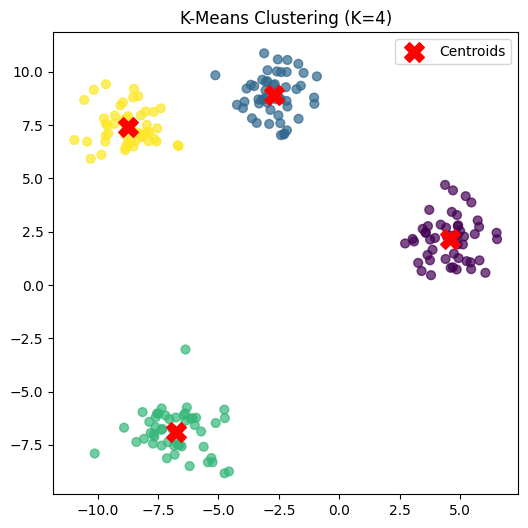

In [8]:
plot_kmeans(4, X)

In [ ]:
def kmeans_iteration_demo(iterations=5, k=4):
    np.random.seed(42)

    centers = X[np.random.choice(len(X), k, replace=True)]

    for i in range(iterations):
        # Assign points
        labels = np.argmin(np.linalg.norm(X[:, None] - centers[None, :], axis=2), axis=1)
        # Plot clusters
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.6)
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200)
        plt.title(f"Iteration {i + 1}")
        plt.show()

        # Update centroids
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers


interact(kmeans_iteration_demo,
         iterations=IntSlider(min=1, max=20, step=1, value=10),
         k=IntSlider(min=2, max=6, step=1, value=4),
         )